# Actividad 2 - Regresión logística

**Aprendizaje Automático - Clase 4**

Objetivo: aplicar regresión logística para predecir el sistema operativo utilizado por un usuario a partir de sus características de navegación web.

Dataset: usuarios_win_mac_lin.csv, proporcionado por el profesor.

Variable objetivo: sistema operativo (Windows, Macintosh o Linux).

## 1. Preparación y organización de los datos

Se carga el dataset proporcionado por el profesor y se organiza en un DataFrame de Pandas para analizar las características de navegación de los usuarios.

In [1]:
import pandas as pd

# Cargar el dataset del profesor
df = pd.read_csv("../Dataset/usuarios_win_mac_lin (1).csv")

# Mostrar los primeros cinco registros
df.head()

,duracion,paginas,acciones,valor,clase
0,7.0,2,4,8,2
1,21.0,2,6,6,2
2,57.0,2,4,4,2
3,101.0,3,6,12,2
4,109.0,2,6,12,2


### Verificación de los datos

Se comprueba la cantidad de registros y variables del dataset, la existencia de valores faltantes y la distribución de usuarios según el sistema operativo.

Esta verificación permite conocer las características de los datos antes de entrenar el modelo de regresión logística.

In [2]:
# Comprobar la cantidad de registros y variables
print("Dimensiones del dataset:", df.shape)

# Comprobar si existen valores faltantes
print("\nValores faltantes:")
print(df.isnull().sum())

# Comprobar la cantidad de usuarios por sistema operativo
print("\nUsuarios por sistema operativo:")
print(df["clase"].value_counts().sort_index())

Dimensiones del dataset: (170, 5)

Valores faltantes:
duracion    0
paginas     0
acciones    0
valor       0
clase       0
dtype: int64

Usuarios por sistema operativo:
clase
0    86
1    40
2    44
Name: count, dtype: int64


## Exploración de los datos (EDA)

### Distribución de usuarios por sistema operativo

Se utiliza un gráfico de barras para visualizar la cantidad de usuarios de Windows, Macintosh y Linux presentes en el dataset.

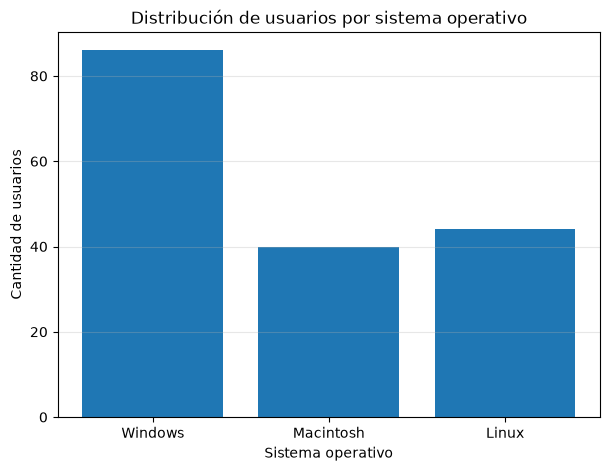

In [9]:
import matplotlib.pyplot as plt

# Cantidad de usuarios por sistema operativo
conteo = df["clase"].value_counts().sort_index()

# Crear el gráfico de barras
plt.figure(figsize=(7, 5))

plt.bar(["Windows", "Macintosh", "Linux"], conteo)

plt.xlabel("Sistema operativo")
plt.ylabel("Cantidad de usuarios")
plt.title("Distribución de usuarios por sistema operativo")

plt.grid(axis="y", alpha=0.3)
plt.show()

**Interpretación:** Se observa que Windows es el sistema operativo más frecuente, con 86 usuarios, seguido de Linux con 44 y Macintosh con 40. La distribución muestra un predominio de Windows, mientras que Linux y Macintosh presentan cantidades similares.

### Distribución de la duración de las visitas

Se utiliza un histograma para explorar cuánto tiempo permanecen los usuarios en la página web durante sus sesiones.

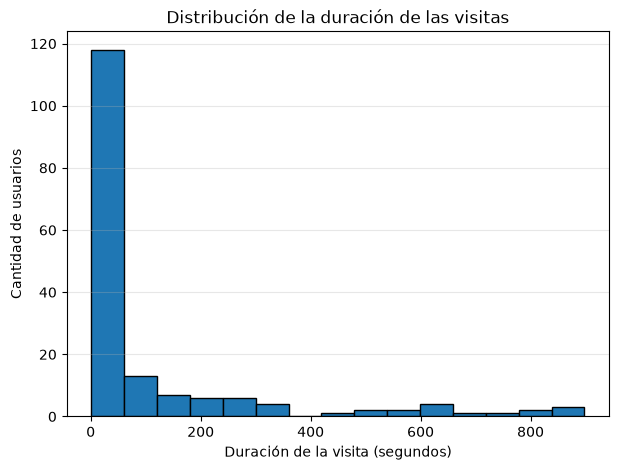

In [10]:
# Explorar la duración de las visitas de los usuarios

plt.figure(figsize=(7, 5))

plt.hist(df["duracion"], bins=15, edgecolor="black")

plt.xlabel("Duración de la visita (segundos)")
plt.ylabel("Cantidad de usuarios")
plt.title("Distribución de la duración de las visitas")

plt.grid(axis="y", alpha=0.3)
plt.show()

**Interpretación:** La mayoría de los usuarios realiza visitas de corta duración. La frecuencia disminuye a medida que aumenta el tiempo de navegación, aunque se observan algunas sesiones considerablemente más prolongadas.

## 2. Modelado de datos

Se utilizará regresión logística para predecir el sistema operativo de los usuarios a partir de cuatro características de navegación.

Se separan las variables predictoras de la variable objetivo y se dividen los datos en entrenamiento y prueba.

In [3]:
# Separar las variables predictoras y la variable objetivo
X = df.drop(columns=["clase"])
y = df["clase"]

# Comprobar las dimensiones
print("Variables predictoras:", X.shape)
print("Variable objetivo:", y.shape)

Variables predictoras: (170, 4)
Variable objetivo: (170,)


### División de los datos en entrenamiento y prueba

Se divide el dataset en 80 % para entrenamiento y 20 % para prueba, conservando la proporción de usuarios de cada sistema operativo en ambos grupos.

In [4]:
from sklearn.model_selection import train_test_split

# Dividir los datos en entrenamiento (80 %) y prueba (20 %)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Comprobar la cantidad de usuarios en cada grupo
print("Usuarios para entrenamiento:", X_train.shape[0])
print("Usuarios para prueba:", X_test.shape[0])

Usuarios para entrenamiento: 136
Usuarios para prueba: 34


### Entrenamiento del modelo de regresión logística

Se entrena un modelo de regresión logística utilizando las cuatro variables predictoras y los datos de los 136 usuarios destinados al entrenamiento.

El objetivo es aprender a clasificar a los usuarios según su sistema operativo: Windows, Macintosh o Linux.

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Estandarizar las variables predictoras
escalador = StandardScaler()

X_train_scaled = escalador.fit_transform(X_train)
X_test_scaled = escalador.transform(X_test)

# Crear el modelo de regresión logística
modelo = LogisticRegression(max_iter=1000)

# Entrenar el modelo
modelo.fit(X_train_scaled, y_train)

print("Modelo entrenado correctamente")

Modelo entrenado correctamente


### Predicción del sistema operativo

Se utiliza el modelo entrenado para predecir el sistema operativo de los 34 usuarios reservados para prueba y comparar las predicciones con los valores reales.

In [6]:
# Realizar predicciones con los datos de prueba
y_pred = modelo.predict(X_test_scaled)

# Comparar los primeros diez resultados
resultados = pd.DataFrame({
    "Sistema real": y_test.values,
    "Sistema predicho": y_pred
})

resultados.head(10)

,Sistema real,Sistema predicho
0,2,2
1,0,0
2,2,2
3,2,2
4,2,2
5,0,2
6,0,0
7,0,2
8,2,2
9,1,0


### Evaluación del modelo

Se evalúa la capacidad del modelo para clasificar correctamente los sistemas operativos mediante la exactitud, la matriz de confusión y el informe de clasificación.

In [7]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Calcular la exactitud del modelo
accuracy = accuracy_score(y_test, y_pred)

print("Exactitud del modelo:", accuracy)

# Mostrar la matriz de confusión
print("\nMatriz de confusión:")
print(confusion_matrix(y_test, y_pred))

# Mostrar el informe de clasificación
print("\nInforme de clasificación:")
print(classification_report(
    y_test, y_pred,
    target_names=["Windows", "Macintosh", "Linux"],
    zero_division=0
))

Exactitud del modelo: 0.7058823529411765

Matriz de confusión:
[[12  0  5]
 [ 4  3  1]
 [ 0  0  9]]

Informe de clasificación:
              precision    recall  f1-score   support

     Windows       0.75      0.71      0.73        17
   Macintosh       1.00      0.38      0.55         8
       Linux       0.60      1.00      0.75         9

    accuracy                           0.71        34
   macro avg       0.78      0.69      0.67        34
weighted avg       0.77      0.71      0.69        34



### Visualización de la matriz de confusión

Se representa gráficamente la matriz de confusión para observar los aciertos y errores del modelo al clasificar los usuarios según su sistema operativo.

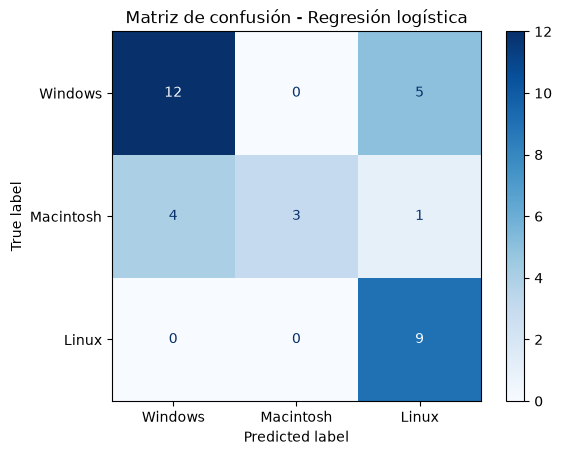

In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Graficar la matriz de confusión
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Windows", "Macintosh", "Linux"],
    cmap="Blues"
)

plt.title("Matriz de confusión - Regresión logística")
plt.show()

## 3. Conclusión

Se aplicó un modelo de regresión logística para predecir el sistema operativo de los usuarios a partir de cuatro características de navegación web.

El modelo se entrenó con 136 usuarios y se evaluó con los 34 restantes.

La exactitud obtenida fue del 70,59 %, clasificando correctamente a 24 usuarios y cometiendo errores en 10 casos.

La matriz de confusión permitió observar que el modelo identificó correctamente a todos los usuarios de Linux del conjunto de prueba, mientras que presentó mayores dificultades para clasificar a los usuarios de Macintosh.

Se concluye que la regresión logística permitió realizar predicciones sobre el sistema operativo, aunque los resultados muestran que existen diferencias en su capacidad para identificar cada clase.